In [8]:
# In Jupyter notebook cell, prefix with ! to run shell commands
!pip install pandas scikit-learn matplotlib seaborn joblib -q
 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_curve, auc
)



In [6]:
# Load dataset
df = pd.read_csv(r"C:\Users\HI\OneDrive\Desktop\project-3\cancer_detection_dataset_realistic.csv")

In [7]:
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (300, 11)
          age  blood_pressure  cholesterol  tumor_size  glucose_level  \
0   96.182363       33.461871    49.337004   19.357852      73.800859   
1  105.842046       49.319206    81.846073   19.528421      92.113921   
2   94.637816       62.269482    49.547617   31.193593      93.115255   
3   78.939188       45.804045    65.629683   23.236862      99.601942   
4   95.904408       41.872626    87.266873   35.335048      78.334799   

         bmi  white_blood_cell_count  red_blood_cell_count  platelet_count  \
0  40.793773               10.780223             91.211073       37.627065   
1  57.616436               20.283091             79.315465       48.183157   
2  34.237151               19.963537             79.016668       55.693163   
3  49.757321               17.976693             78.676319       59.812926   
4  43.736670               15.890291             75.727608       48.226424   

   heart_rate  cancer  
0   27.406767       0  
1   54.230172      

In [9]:
# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# --- Preprocessing ---
# Assume target column is 'cancer' (adjust if different in dataset)
X = df.drop('cancer', axis=1)
y = df['cancer']


Missing Values:
 age                       0
blood_pressure            0
cholesterol               0
tumor_size                0
glucose_level             0
bmi                       0
white_blood_cell_count    0
red_blood_cell_count      0
platelet_count            0
heart_rate                0
cancer                    0
dtype: int64


In [10]:
# One-hot encode categorical variables if present
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [12]:
# --- Logistic Regression Classifier ---
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

In [13]:
print("\n--- Logistic Regression Results ---")
print("Classification Report:\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))



--- Logistic Regression Results ---
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.95      0.78        40
           1       0.33      0.05      0.09        20

    accuracy                           0.65        60
   macro avg       0.50      0.50      0.44        60
weighted avg       0.56      0.65      0.55        60

Confusion Matrix:
 [[38  2]
 [19  1]]


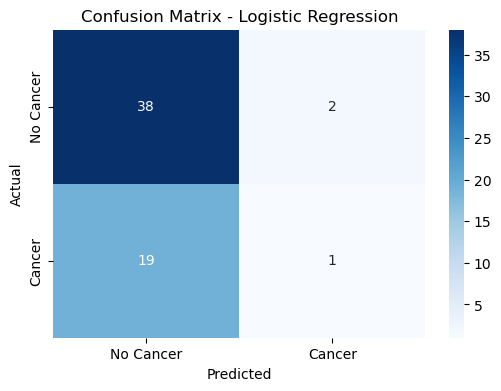

In [14]:
# --- Visualization Section ---

# 1. Confusion Matrix Heatmap (Logistic Regression)
conf_mat = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_mat, annot=True, fmt='d', cmap='Blues',
    xticklabels=["No Cancer", "Cancer"],
    yticklabels=["No Cancer", "Cancer"]
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

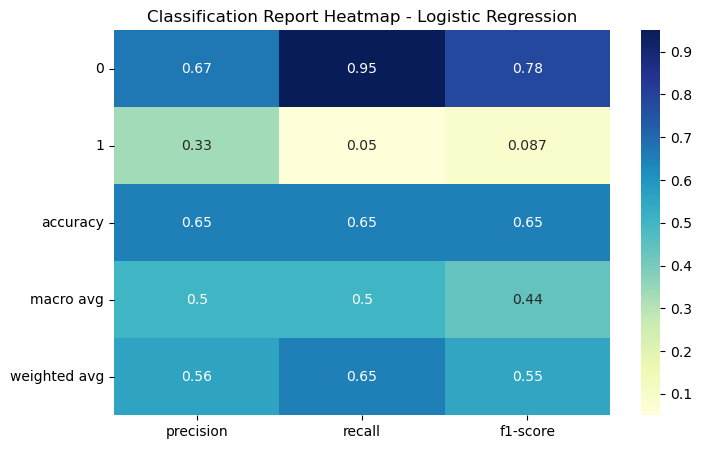

In [15]:
# 2. Classification Report Heatmap
report = classification_report(y_test, y_pred_lr, output_dict=True)
df_report = pd.DataFrame(report).iloc[:-1, :].T
plt.figure(figsize=(8, 5))
sns.heatmap(df_report, annot=True, cmap='YlGnBu')
plt.title("Classification Report Heatmap - Logistic Regression")
plt.show()

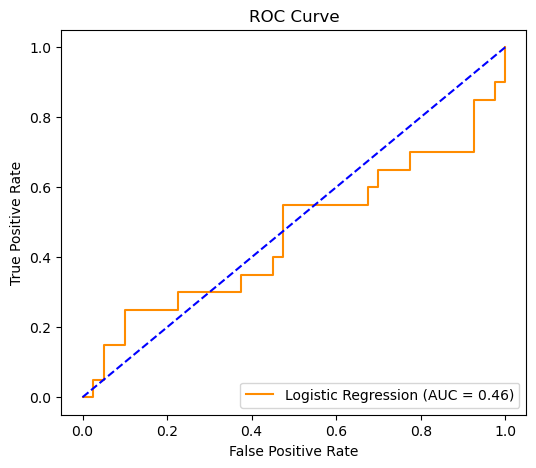

In [16]:
# 3. ROC Curve
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='blue')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [17]:
# --- KNN Classifier for Comparison ---
k_values = range(1, 21)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracy_scores.append(acc)
   

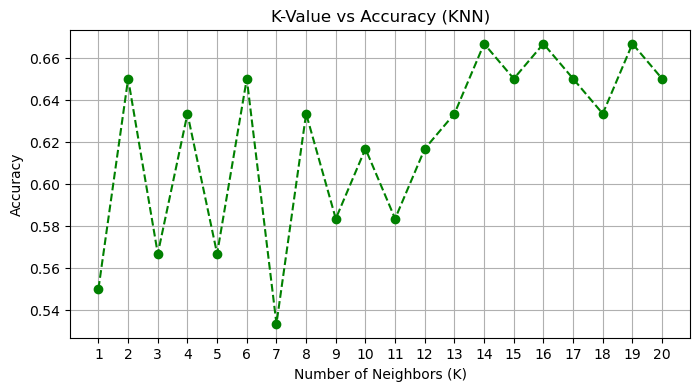

In [18]:
# 4. K-Value vs Accuracy
plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracy_scores, marker='o', linestyle='--', color='green')
plt.title("K-Value vs Accuracy (KNN)")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.show()


In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.65
